# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [4]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

# TODO: carga el archivo en un DataFrame llamado df
df = pd.read_csv(DATA_PATH)
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
# TODO: reporta forma, tipos, nulos, duplicados y distribución de target

print("Forma (filas, columnas):", df.shape)

print("\nTipos de dato:")
print(df.dtypes)

print("\nNulos por columna:")
print(df.isna().sum())

print("\nFilas duplicadas:", df.duplicated().sum())

print("\nDistribucion de target (conteo):")
print(df["target"].value_counts().sort_index())

print("\nDistribucion de target (proporcion):")
print(df["target"].value_counts(normalize=True).sort_index().round(4))


Forma (filas, columnas): (178, 14)

Tipos de dato:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue            

**Conclusión de calidad:**

> El dataset tiene 178 registros y 14 columnas: 13 variables químicas leídas como `float64` y el target como `int64` con valores 0, 1 y 2. No hay valores nulos en ninguna columna, no hay filas duplicadas y ningún campo numérico quedó interpretado como texto, así que no fue necesario imputar, eliminar registros ni corregir tipos. Se trabaja con los 178 registros completos.
>
> La única observación es la distribución del target, que no es uniforme: 59, 71 y 48 ejemplos (33,2 % / 39,9 % / 27,0 %). El desbalance es leve, pero con solo 48 ejemplos en la clase minoritaria un split aleatorio podría dejar muy pocos casos de esa clase en el conjunto de test y volver inestable la métrica final. Por eso la partición se hace **estratificada por `target`** y con `random_state` fijo, para conservar esas proporciones en train y test y que el resultado sea reproducible.


## 2. Split train/test

In [6]:
# TODO: crea train_df (80 %) y test_df (20 %)
# Requisitos: stratify=df["target"] y random_state=RANDOM_STATE

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

print("Proporcion de clases en train:")
print(train_df["target"].value_counts(normalize=True).sort_index().round(4))

print("\nProporcion de clases en test:")
print(test_df["target"].value_counts(normalize=True).sort_index().round(4))


Proporcion de clases en train:
target
0    0.3310
1    0.4014
2    0.2676
Name: proportion, dtype: float64

Proporcion de clases en test:
target
0    0.3333
1    0.3889
2    0.2778
Name: proportion, dtype: float64


In [7]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

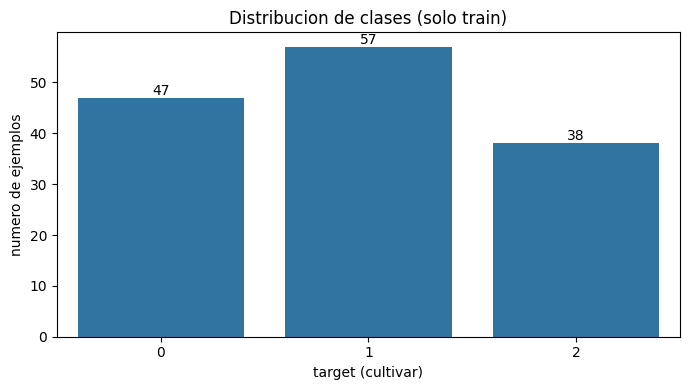

Resumen de escalas (solo train):
                                 min      max    mean     std
alcohol                        11.03    14.83   12.97    0.80
malic_acid                      0.74     5.80    2.34    1.10
ash                             1.36     3.22    2.36    0.27
alcalinity_of_ash              10.60    30.00   19.63    3.38
magnesium                      70.00   162.00   99.63   14.94
total_phenols                   0.98     3.88    2.27    0.62
flavanoids                      0.34     3.74    1.99    0.95
nonflavanoid_phenols            0.13     0.63    0.36    0.12
proanthocyanins                 0.42     3.58    1.60    0.58
color_intensity                 1.28    13.00    4.99    2.33
hue                             0.48     1.71    0.95    0.23
od280/od315_of_diluted_wines    1.27     3.92    2.61    0.69
proline                       278.00  1515.00  739.48  301.50


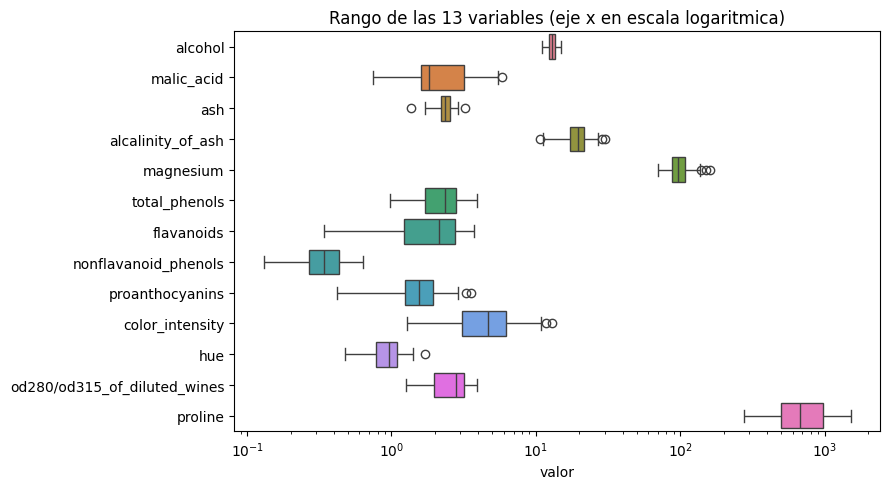

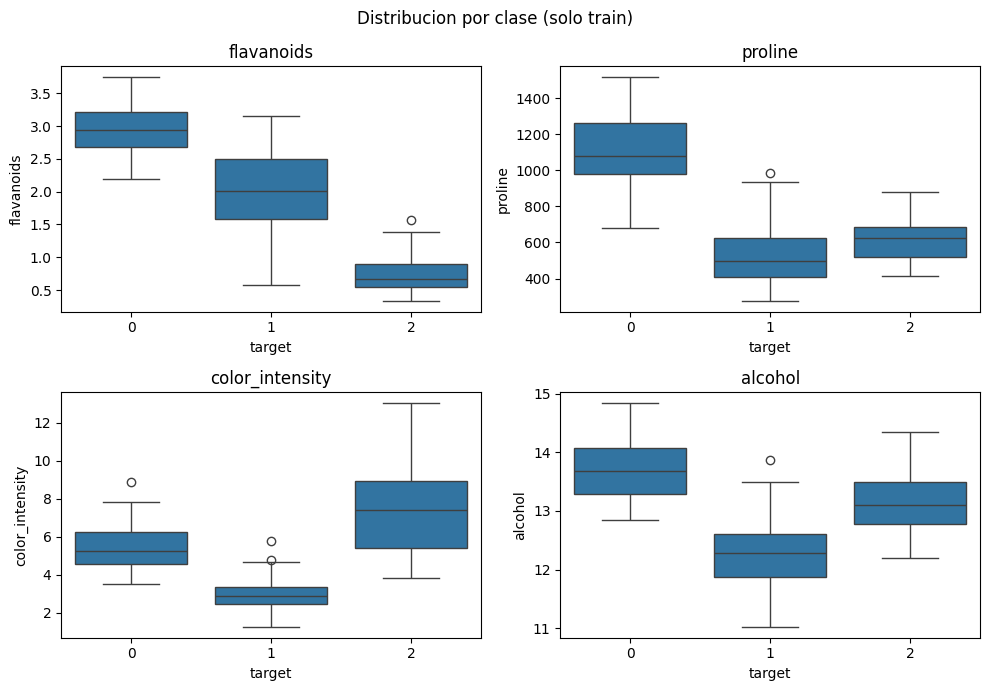

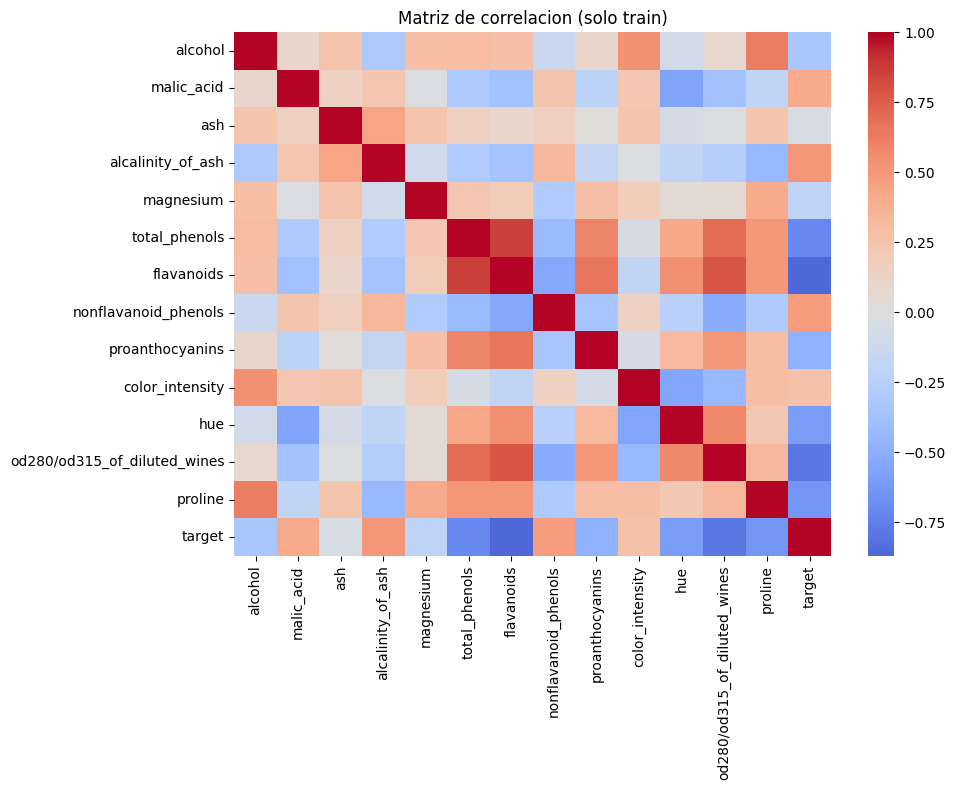


Correlacion de cada variable con target, ordenada por magnitud:
flavanoids                     -0.870
od280/od315_of_diluted_wines   -0.784
total_phenols                  -0.714
proline                        -0.639
hue                            -0.606
alcalinity_of_ash               0.508
proanthocyanins                -0.481
nonflavanoid_phenols            0.477
malic_acid                      0.418
alcohol                        -0.332
color_intensity                 0.269
magnesium                      -0.208
ash                            -0.045
Name: target, dtype: float64


In [8]:
# TODO: crea al menos tres visualizaciones usando solamente train_df

# --- 1. Distribucion de clases -------------------------------------------
fig, ax = plt.subplots()
sns.countplot(data=train_df, x="target", ax=ax)
ax.set_title("Distribucion de clases (solo train)")
ax.set_xlabel("target (cultivar)")
ax.set_ylabel("numero de ejemplos")
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.tight_layout()
plt.show()

# --- 2. Escala de cada variable ------------------------------------------
print("Resumen de escalas (solo train):")
print(train_df.drop(columns="target").describe().T[["min", "max", "mean", "std"]].round(2))

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=train_df.drop(columns="target"), orient="h", ax=ax)
ax.set_xscale("log")
ax.set_title("Rango de las 13 variables (eje x en escala logaritmica)")
ax.set_xlabel("valor")
plt.tight_layout()
plt.show()

# --- 3. Distribucion por clase de cuatro variables ------------------------
variables = ["flavanoids", "proline", "color_intensity", "alcohol"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for variable, ax in zip(variables, axes.ravel()):
    sns.boxplot(data=train_df, x="target", y=variable, ax=ax)
    ax.set_title(variable)
    ax.set_xlabel("target")
fig.suptitle("Distribucion por clase (solo train)")
plt.tight_layout()
plt.show()

# --- 4. Matriz de correlacion --------------------------------------------
corr = train_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlacion (solo train)")
plt.tight_layout()
plt.show()

print("\nCorrelacion de cada variable con target, ordenada por magnitud:")
print(corr["target"].drop("target").sort_values(key=abs, ascending=False).round(3))


**Hallazgos:**

1. **Las variables están en escalas incomparables.** `proline` va de 278 a 1515 (desviación 301,5), mientras `hue` va de 0,48 a 1,71 (desviación 0,23) y `nonflavanoid_phenols` de 0,13 a 0,63: hay tres órdenes de magnitud entre la variable más grande y la más pequeña. Los modelos que dependen de distancias o de gradiente —KNN y regresión logística— calcularían una distancia dominada casi por completo por `proline`, así que requieren estandarización. El árbol de decisión no la necesita, porque no mide distancias sino que corta cada variable por separado con su propio umbral. Por eso en la etapa de entrenamiento se preparan **dos preprocesadores distintos**, uno con escalado y otro sin él.

2. **Varias variables tienen alto poder discriminante.** Las más informativas frente al target son `flavanoids` (−0,870), `od280/od315_of_diluted_wines` (−0,784), `total_phenols` (−0,714) y `proline` (−0,639). Las medias por clase lo confirman: `flavanoids` promedia 2,93 / 2,01 / 0,78 en las clases 0, 1 y 2, y `proline` promedia 1092 / 526 / 623. Es decir, `flavanoids` aísla bien la clase 2 y `proline` aísla bien la clase 0, de modo que combinadas las tres clases quedan casi separadas. Se espera entonces un desempeño alto (accuracy por encima del 90 %) incluso con modelos simples; un resultado muy por debajo apuntaría a un error en el pipeline antes que a un límite del dataset.

   *Reserva metodológica:* `target` es una variable **nominal** —los códigos 0, 1 y 2 identifican cultivares y no implican ningún orden—, así que la correlación de Pearson con el target solo sirve como indicio de tendencia monótona. La evidencia sólida de separabilidad son los boxplots por clase y las medias, no el coeficiente.

3. **Hay multicolinealidad entre las variables fenólicas.** `total_phenols` correlaciona 0,861 con `flavanoids`, y `od280/od315_of_diluted_wines` correlaciona 0,786 con `flavanoids`: las tres miden información en buena parte redundante. Esto no obliga a eliminar columnas, pero condiciona la interpretación del modelo: en la regresión logística los coeficientes de variables redundantes se reparten de forma inestable, y en el árbol la importancia de features se distribuye de manera arbitraria entre ellas. Cualquier afirmación del tipo "la variable más importante es X" en la etapa de evaluación debe hacerse con esta reserva.


## 4. Persistencia de datos y contrato

In [9]:
# TODO: reinicia los índices y guarda train.csv y test.csv sin el índice
# TODO: crea data_contract.json con target, features, random_state y test_size

TARGET = "target"
TEST_SIZE = 0.2

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_df.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

FEATURES = [columna for columna in train_df.columns if columna != TARGET]

data_contract = {
    "target": TARGET,
    "features": FEATURES,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "n_train": len(train_df),
    "n_test": len(test_df),
    "classes": sorted(train_df[TARGET].unique().tolist()),
}

with open(ARTIFACTS_DIR / "data_contract.json", "w", encoding="utf-8") as archivo:
    json.dump(data_contract, archivo, indent=2, ensure_ascii=False)

print(json.dumps(data_contract, indent=2, ensure_ascii=False))


{
  "target": "target",
  "features": [
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280/od315_of_diluted_wines",
    "proline"
  ],
  "random_state": 42,
  "test_size": 0.2,
  "n_train": 142,
  "n_test": 36,
  "classes": [
    0,
    1,
    2
  ]
}


In [ ]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


: 

## Checklist

- [x] Cargué el CSV desde `data/raw`.
- [x] Revisé calidad y distribución de la clase.
- [x] Realicé un split estratificado.
- [x] No exploré el conjunto de test.
- [x] Guardé los tres artefactos requeridos.